# Mamba-3-XR: Pre-training Pipeline with Kronecker-MoE

本專案實作了 **Mamba-3** 預訓練流程，這是一款基於改進型選擇性狀態空間模型 (Selective State Space Model, SSM) 並整合了 **Kronecker 分解混合專家系統 (Kronecker-MoE)** 的先進架構。

### 🚀 核心創新亮點 (Core Innovations):
- **Mamba-3 架構**: 採用 MIMO (Multi-Input Multi-Output) 與改進的 Parallel Scan，強化了序列建模的並行性與表達能力。
- **Kronecker-MoE (K-MoE)**: 透過 Kronecker 積將專家權重矩陣分解，大幅降低參數量（Parameter-Efficient），同時保持極高的專家容量。
- **4:1 混合主幹 (Hybrid Backbone)**: 交錯排列 Mamba 層與 Transformer 層（每 4 層 Mamba 接 1 層 Transformer）。
- **硬體優化 (Hardware Optimized)**: 本階段採用 **NVIDIA T4 x 2** 分散式訓練，支援 `fp16` 混合精度。

### 📊 模型規格與參數概覽 (Model Specs):
```text
Total Parameters: 186.14M
├─ Mamba Layers (20 x K-MoE Mamba3Block): 136.61M
├─ Transformer Layers (5 x Causal Attn + K-MoE FFN): 24.95M
├─ Embeddings & Head: 24.58M
└─ MoE Routing & Expert Params: 25.93M
    └─ Per-Expert Param Counts (A,B Kronecker mats only):
       • Experts shape (8x8 → 16x16), 256 experts: 0.26K params / expert
       • Experts shape (48x64 → 24x32), 256 experts: 3.20K params / expert
       • Experts shape (24x32 → 48x64), 256 experts: 3.20K params / expert
```

### 🏗️ 層級堆疊結構 (Layer Stack):
```text
=== Layer Stack (4:1 Mamba-Transformer Interleaved, 25 total layers) ===
  [Embedding]  d_model=768, vocab=32000
  --- Macro Block 1/5 ---
  Layer 01 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 02 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 03 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 04 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 05 │ 🟠 Transformer  (Causal Attn 12 heads + K-MoE FFN experts=256)
  --- Macro Block 2/5 ---
  Layer 06 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 07 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 08 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 09 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 10 │ 🟠 Transformer  (Causal Attn 12 heads + K-MoE FFN experts=256)
  --- Macro Block 3/5 ---
  Layer 11 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 12 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 13 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 14 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 15 │ 🟠 Transformer  (Causal Attn 12 heads + K-MoE FFN experts=256)
  --- Macro Block 4/5 ---
  Layer 16 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 17 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 18 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 19 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 20 │ 🟠 Transformer  (Causal Attn 12 heads + K-MoE FFN experts=256)
  --- Macro Block 5/5 ---
  Layer 21 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 22 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 23 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 24 │ 🔵 Mamba3 KMoE  (d_model=768, d_state=64, K-MoE experts=256)
  Layer 25 │ 🟠 Transformer  (Causal Attn 12 heads + K-MoE FFN experts=256)
  [LM Head]    tied weights
```

---


## 🛠️ 第一階段：環境初始化與資料準備 (Setup & Data)

在此區塊中，我們定義工具函數、掛載訓練資料，並處理 CSV 日誌的格式一致性，確保訓練指標能被正確追蹤與可視化。

In [ ]:
import os
import shutil

# --- Kaggle Environment Path Setup ---
KAGGLE_INPUT = "/kaggle/input/datasets/s990093/checkpoint"
WORKING_DIR = "/kaggle/working"

def sync_checkpoint(filename, is_log=False):
    src = os.path.join(KAGGLE_INPUT, filename)
    dst = os.path.join(WORKING_DIR, filename)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ {filename} {'日誌' if is_log else '權重'} 複製完成")
    else:
        print(f"⚠️ 找不到 {filename}，將從頭開始")

sync_checkpoint("colab_training_log.csv", is_log=True)
sync_checkpoint("mamba3_colab_checkpoint.pt")


## 🧠 第二階段：核心架構定義 (Architecture & Model)

Mamba-3 結合了 SSM 的效率與 Transformer 的建模深度。以下是核心組件的技術細節：

### 1. Kronecker-MoE (K-MoE)
傳統 MoE 中，專家層的參數隨專家數量 $N$ 線性增長。K-MoE 透過 Kronecker 積 $W = A \otimes B$ 將大矩陣分解為兩個小矩陣，將參數量從 $O(D_{in} \times D_{out})$ 降低到 $O(\sqrt{D_{in}} + \sqrt{D_{out}})$ 的級別。這使得我們可以在 A100 上部署數百個專家而不會耗盡顯存。

### 2. Mamba-3 MIMO Block
Mamba-3 改進了傳統 Mamba 的輸入/輸出映射，支援多輸入/多輸出的狀態轉移，大幅提升了對複雜序列模式的捕捉能力，並透過 `chunk_parallel_scan` 最佳化了 GPU 上的計算吞吐量。

### 3. 4:1 Hybrid Backbone
研究顯示，完全由 SSM 組成的模型在某些全局關聯任務上略遜於 Transformer。我們採用 4 層 Mamba + 1 層 Transformer 的交錯結構，利用 Mamba 處理長程狀態與降低計算開銷，並透過 Transformer 強化局部的注意力機制。

---

### ⏱️ 訓練時長統計 (Training Duration):
- **累積總訓練時數**: **17.31 小時** (跨 A100 與 T4 階段)


### 📝 訓練腳本生成 (Script Generation)

以下區塊將生成 `train.py`。該腳本集成了上述架構，並配置了 Fused AdamW 與 Cosine Decay LR Schedule。

In [ ]:
%%writefile train.py
# =============================================================================
# MAMBA-3: IMPROVED SELECTIVE STATE SPACE MODEL WITH KRONECKER-MOE
# Training Stage: High-Performance Compute (NVIDIA A100)
# =============================================================================

import os
import glob
import math
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint
from torch.utils.data import IterableDataset, DataLoader, get_worker_info

from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import sentencepiece as spm
from accelerate import Accelerator
import gc
import numpy as np
import shutil
import multiprocessing
import warnings

# --- Environmental Configuration ---
warnings.filterwarnings("ignore", message="Online softmax is disabled on the fly.*")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def detect_precision_mode():
    """Determines the optimal mixed precision mode based on GPU architecture."""
    if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8:
        # Ampere or newer (A100, RTX 30/40 series)
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("🚀 High-End GPU Detected (Ampere+). Enabling bf16 and TF32 optimizations.")
        return "bf16"
    else:
        # T4 / V100 or older
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        print("🐢 Standard GPU Detected (T4/V100). Falling back to fp16 precision.")
        return "fp16"

MIXED_PRECISION = detect_precision_mode()

# 之後在初始化 Accelerator 時改成：
# accelerator = Accelerator(mixed_precision=MIXED_PRECISION)


# =============================================================================
# 1. ARCHITECTURE CONFIGURATION
# =============================================================================
class Mamba3Config:
    """
    Configuration class for the Mamba-3 architecture.
    Incorporates Kronecker-decomposed Mixture of Experts (K-MoE) parameters.
    """
    def __init__(
        self,
        d_model: int = 768,           # Model dimension
        d_state: int = 64,            # SSM state dimension
        d_head: int = 64,             # Attention/Mamba head dimension
        n_groups: int = 1,            # Grouped state-space parameter count
        mimo_rank: int = 4,           # Kronecker MIMO rank
        expand: int = 4,              # Expansion factor for inner dimension
        num_layers: int = 15,         # Number of hybrid macro-blocks
        use_conv: bool = False,       # Toggle local convolution
        d_conv: int = 4,              # Convolution kernel size
        rms_norm_eps: float = 1e-5,   # Stability epsilon for RMSNorm
        chunk_size: int = 65,         # Parallel scan block size
        use_parallel_scan: bool = True,

        # --- K-MoE (Kronecker Mixture of Experts) ---
        use_kmoe: bool = True,
        kmoe_num_experts: int = 1024,
        kmoe_top_k: int = 2,

        # --- SSM Initialization Parameters ---
        dt_min: float = 0.001,
        dt_max: float = 0.1,
        dt_init_floor: float = 1e-4,
        dt_limit=(0.0, float("inf")),
        A_init_range=(1, 16),
    ):
        self.d_model = d_model
        self.d_state = d_state
        self.d_head = d_head
        self.expand = expand
        self.num_layers = num_layers

        self.d_inner = int(expand * d_model)
        assert self.d_inner % d_head == 0, "Inner dimension must be divisible by head dimension."
        self.n_heads = self.d_inner // d_head

        assert self.n_heads % n_groups == 0, f"n_heads ({self.n_heads}) must be divisible by n_groups."
        self.n_groups = n_groups
        self.mimo_rank = mimo_rank
        self.use_conv = use_conv
        self.d_conv = d_conv
        self.rms_norm_eps = rms_norm_eps
        self.chunk_size = chunk_size
        self.use_parallel_scan = use_parallel_scan

        self.use_kmoe = use_kmoe
        self.kmoe_num_experts = kmoe_num_experts
        self.kmoe_top_k = kmoe_top_k

        self.dt_min = dt_min
        self.dt_max = dt_max
        self.dt_init_floor = dt_init_floor
        self.dt_limit = dt_limit
        self.A_init_range = A_init_range

# =============================================================================
# 2. NORMALIZATION LAYER
# =============================================================================
class RMSNorm(nn.Module):
    """Root Mean Square Layer Normalization for improved numerical stability."""
    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rrms = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x * rrms * self.weight

# ==========================================
# 3. KroneckerMoE
# ==========================================
class KroneckerMoE(nn.Module):
    def __init__(self, dim_in1, dim_in2, dim_out1, dim_out2, num_experts=1024, top_k=2):
        super().__init__()
        self.dim_in1 = dim_in1
        self.dim_in2 = dim_in2
        self.dim_out1 = dim_out1
        self.dim_out2 = dim_out2
        self.num_experts = num_experts
        self.top_k = min(top_k, num_experts)

        self.router = nn.Linear(dim_in1 * dim_in2, num_experts, bias=False)
        self.A_experts = nn.Parameter(torch.randn(num_experts, dim_out1, dim_in1))
        self.B_experts = nn.Parameter(torch.randn(num_experts, dim_out2, dim_in2))

        std_A = (1.0 / math.sqrt(dim_in1 * dim_out1)) ** 0.5
        std_B = (1.0 / math.sqrt(dim_in2 * dim_out2)) ** 0.5

        nn.init.normal_(self.A_experts, mean=0.0, std=std_A)
        nn.init.normal_(self.B_experts, mean=0.0, std=std_B)
        nn.init.normal_(self.router.weight, mean=0.0, std=0.02)

        self.register_parameter('scale', nn.Parameter(torch.ones(1)))
        self.bias = nn.Parameter(torch.zeros(dim_out1 * dim_out2))

    # 🌟 加上這個裝飾器：防止 torch.compile 在動態迴圈和 Checkpoint 中迷失方向
    # @torch.compiler.disable # ⚠️ 改完之後，你可以大膽把這一行「刪掉」或「註解掉」了！
    def forward(self, x):
        orig_shape = x.shape
        x_flat = x.reshape(-1, self.dim_in1 * self.dim_in2)
        B_flat = x_flat.size(0)

        router_logits = self.router(x_flat)
        router_probs = torch.softmax(router_logits, dim=-1)

        top_k_vals, top_k_indices = torch.topk(router_logits, self.top_k, dim=-1)
        top_k_probs = torch.softmax(top_k_vals, dim=-1)

        if self.training:
            expert_mask = torch.zeros(B_flat, self.num_experts, device=x.device, dtype=torch.float32)
            expert_mask.scatter_(1, top_k_indices, 1.0)
            epoch_f_i = expert_mask.mean(dim=0)
            epoch_P_i = router_probs.float().mean(dim=0)
            aux_loss = self.num_experts * torch.sum(epoch_f_i * epoch_P_i)
            aux_loss = aux_loss.to(x.dtype)
        else:
            aux_loss = torch.tensor(0.0, device=x.device, dtype=x.dtype)

        x_sub = x_flat.reshape(B_flat, self.dim_in1, self.dim_in2)

        # ==========================================
        # 🚀 終極效能優化區塊：無迴圈 Batched Einsum 
        # ==========================================
        # 1. 展開索引，準備一次性抓取所有被選中的專家權重
        # flat_indices 形狀: (B_flat * top_k,)
        flat_indices = top_k_indices.flatten()

        # 2. 根據索引，一次性 Gather 出所有的 A 和 B 矩陣 (A100 記憶體頻寬極大，瞬間完成)
        # A_gathered 形狀: (B_flat * top_k, dim_out1, dim_in1)
        # B_gathered 形狀: (B_flat * top_k, dim_out2, dim_in2)
        A_gathered = self.A_experts[flat_indices]
        B_gathered = self.B_experts[flat_indices]

        # 3. 準備 Token (每個 Token 都要複製 top_k 次對應它的專家)
        # tokens_expanded 形狀: (B_flat * top_k, dim_in1, dim_in2)
        tokens_expanded = x_sub.unsqueeze(1).expand(-1, self.top_k, -1, -1).reshape(B_flat * self.top_k, self.dim_in1, self.dim_in2)

        # 4. 一次性暴力 Einsum (A100 發揮實力的地方，把 256 次 kernel 發射濃縮成 1 次)
        # 'noi' 是 A矩陣, 'nij' 是 Token, 'npj' 是 B矩陣 -> 輸出 'nop'
        Y_computed = torch.einsum('noi, nij, npj -> nop', A_gathered, tokens_expanded, B_gathered)

        # 5. 乘上 Router 的機率
        # flat_probs 形狀: (B_flat * top_k, 1, 1)
        flat_probs = top_k_probs.flatten().unsqueeze(1).unsqueeze(2).to(x.dtype)
        Y_computed = Y_computed * flat_probs

        # 6. 把展開的 top_k 加總回原本的 Token 維度
        # 將 (B_flat * top_k, dim_out1, dim_out2) reshape 回 (B_flat, top_k, dim_out1, dim_out2)
        # 然後沿著 top_k 的維度進行加總
        output = Y_computed.reshape(B_flat, self.top_k, self.dim_out1, self.dim_out2).sum(dim=1)
        # ==========================================

        output = output.reshape(*orig_shape[:-1], -1)
        output = output * self.scale + self.bias
        return output, aux_loss



# ==========================================
# 4. K-MoE Mamba-3 Block
# ==========================================
class Mamba3Block(nn.Module):
    def __init__(self, config: Mamba3Config):
        super().__init__()
        self.config = config
        d_in, H, G, P, N, R = config.d_model, config.n_heads, config.n_groups, config.d_head, config.d_state, config.mimo_rank
        self.ratio = H // G
        self.dim_z = H * P
        self.dim_x = H * P
        self.dim_B = G * N * R
        self.dim_C = G * N * R
        self.dim_dt = G
        self.dim_A = G
        self.dim_lambda = G

        d_proj_total = self.dim_z + self.dim_x + self.dim_B + self.dim_C + self.dim_dt + self.dim_A + self.dim_lambda
        self.in_proj = nn.Linear(d_in, d_proj_total, bias=True)

        if config.use_kmoe:
            def get_factors(n):
                for i in range(int(math.sqrt(n)), 0, -1):
                    if n % i == 0: return i, n // i
                return 1, n
            p1, p2 = get_factors(P)
            q1, q2 = get_factors(P * R)
            self.x_up_proj = KroneckerMoE(p1, p2, q1, q2, config.kmoe_num_experts, config.kmoe_top_k)
        else:
            self.x_up_proj = nn.Linear(P, P * R, bias=False)

        self.y_down_proj = nn.Linear(P * R, P, bias=False)

        self.theta_log = nn.Parameter(torch.randn(G, N // 2))
        self.D = nn.Parameter(torch.ones(H))

        self.norm_B = RMSNorm(N * R, eps=config.rms_norm_eps)
        self.norm_C = RMSNorm(N * R, eps=config.rms_norm_eps)
        self.bias_B = nn.Parameter(torch.zeros(G, N, R))
        self.bias_C = nn.Parameter(torch.zeros(G, N, R))

        if config.use_kmoe:
            d_inner_f1, d_inner_f2 = get_factors(config.d_inner)
            d_in_f1, d_in_f2 = get_factors(d_in)
            self.out_proj = KroneckerMoE(d_inner_f1, d_inner_f2, d_in_f1, d_in_f2, config.kmoe_num_experts, config.kmoe_top_k)
        else:
            self.out_proj = nn.Linear(config.d_inner, d_in, bias=False)

        self.pre_gate_norm = RMSNorm(H * P)
        self.act = nn.SiLU()

        with torch.no_grad():
            if not config.use_kmoe:
                nn.init.xavier_uniform_(self.x_up_proj.weight, gain=1.0 / math.sqrt(R) if R > 1 else 1.0)
            nn.init.xavier_uniform_(self.y_down_proj.weight, gain=1.0 / math.sqrt(R) if R > 1 else 1.0)
            self.bias_B.fill_(1.0)
            self.bias_C.fill_(1.0)
            A_min, A_max = config.A_init_range
            dt = torch.clamp(torch.exp(torch.rand(G) * (math.log(config.dt_max) - math.log(config.dt_min)) + math.log(config.dt_min)), min=config.dt_init_floor)
            inv_dt = dt + torch.log(-torch.expm1(-dt))
            dt_start = self.dim_z + self.dim_x + self.dim_B + self.dim_C
            dt_end = dt_start + self.dim_dt
            A_end = dt_end + self.dim_A
            self.in_proj.bias[dt_start:dt_end].copy_(inv_dt)
            self.in_proj.bias[dt_end:A_end].uniform_(A_min, A_max).log_()
            self.in_proj.bias[A_end:].fill_(-3.0)

    # 🚀 最佳化寫法 (使用 torch.view_as_complex)：
    def apply_rope(self, x, angles):
        # x 形狀: (B, L, H, N, R) 
        # angles 形狀: (B, L, H, N/2)
        N_half = angles.shape[-1]

        # 1. 針對 N 維度拆出實部與虛部
        # 形狀變為: (B, L, H, N/2, 2, R)
        x_reshaped = x.float().view(*x.shape[:-2], N_half, 2, x.shape[-1])

        # 2. 將 2 這個維度換到最後面，並確保記憶體連續，才能觸發底層複數轉換
        # 形狀變為: (B, L, H, N/2, R, 2)
        x_transposed = x_reshaped.transpose(-1, -2).contiguous()

        # 3. 轉換為複數張量
        # 形狀變為: (B, L, H, N/2, R)
        x_complex = torch.view_as_complex(x_transposed)

        # 4. 準備旋轉頻率
        # angles 擴展為: (B, L, H, N/2, 1) 以便跟 R 維度廣播
        freqs_complex = torch.polar(
            torch.ones_like(angles, dtype=torch.float32), 
            angles.float()
        ).unsqueeze(-1)

        # 5. 複數相乘完成旋轉 (GPU 內部會自動處理 R 維度的廣播)
        x_rotated = x_complex * freqs_complex

        # 6. 轉回實數，再把維度搬回原樣
        # 轉回實數形狀: (B, L, H, N/2, R, 2)
        x_rotated_real = torch.view_as_real(x_rotated)
        
        # 轉置回來 (..., N/2, 2, R)，最後 reshape 復原 (..., N, R)
        return x_rotated_real.transpose(-1, -2).reshape_as(x).type_as(x)
        
    def segsum(self, x):
        T = x.size(-1)
        x_cumsum = torch.cumsum(x, dim=-1)
        x_segsum = x_cumsum[..., :, None] - x_cumsum[..., None, :]
        mask = torch.tril(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=0)
        return x_segsum.masked_fill(~mask, -float('inf'))

    def chunk_parallel_scan(self, u, dt, A, C, chunk_size=128):
        B, L, H, N, P = u.shape
        R, device, input_dtype = C.shape[-1], u.device, u.dtype
        L_orig = L
        if L % chunk_size != 0:
            pad_len = chunk_size - (L % chunk_size)
            u = F.pad(u, (0, 0, 0, 0, 0, 0, 0, pad_len))
            dt = F.pad(dt, (0, 0, 0, pad_len))
            C = F.pad(C, (0, 0, 0, 0, 0, 0, 0, pad_len))
            L = L + pad_len
        log_alpha = dt * A
        num_chunks = L // chunk_size
        u_chunk = u.view(B, num_chunks, chunk_size, H, N, P)
        dt_chunk = dt.view(B, num_chunks, chunk_size, H)
        log_alpha_chunk = log_alpha.view(B, num_chunks, chunk_size, H)
        C_chunk = C.view(B, num_chunks, chunk_size, H, N, R)

        log_alpha_perm = log_alpha_chunk.permute(0, 1, 3, 2)
        L_mask = torch.exp(self.segsum(log_alpha_perm))

        BCH = B * num_chunks * H
        L_mask_flat = L_mask.reshape(BCH, chunk_size, chunk_size)
        u_chunk_flat = u_chunk.permute(0, 1, 3, 2, 4, 5).reshape(BCH, chunk_size, N * P)
        h_intra = torch.matmul(L_mask_flat, u_chunk_flat).reshape(B, num_chunks, H, chunk_size, N, P).permute(0, 1, 3, 2, 4, 5)

        batch_dims = B * num_chunks * chunk_size * H
        h_trans = h_intra.permute(0, 1, 2, 3, 5, 4).reshape(batch_dims, P, N)
        c_for_mat = C_chunk.reshape(batch_dims, N, R)
        y_diag = torch.matmul(h_trans, c_for_mat).reshape(B, num_chunks, chunk_size, H, P, R)

        decay_chunk = torch.exp(torch.sum(log_alpha_chunk, dim=2))
        h_chunk_final = h_intra[:, :, -1]
        h_prev = torch.zeros(B, H, N, P, device=device, dtype=input_dtype)
        h_states_inter = []
        for c in range(num_chunks):
            h_states_inter.append(h_prev)
            h_prev = h_prev * decay_chunk[:, c].view(B, H, 1, 1) + h_chunk_final[:, c]
        h_states_inter = torch.stack(h_states_inter, dim=1)

        decay_intra = torch.exp(torch.cumsum(log_alpha_chunk, dim=2))
        c_decayed = C_chunk * decay_intra.unsqueeze(-1).unsqueeze(-1)

        # 2) 將中間 hidden 狀態轉成 [..., P, N]，讓 matmul 自動廣播
        # h_states_inter: [B, num_chunks, H, N, P] → [B, num_chunks, 1, H, P, N]
        h_inter_trans = h_states_inter.unsqueeze(2).transpose(-1, -2)

        # 3) 廣播 matmul：[..., P, N] @ [..., N, R] → [..., P, R]
        y_off = torch.matmul(h_inter_trans, c_decayed)
        y_total = y_diag + y_off

        y_total = y_total.view(B, L, H, P, R)
        if L_orig < L:
            y_total = y_total[:, :L_orig]
        return y_total.to(input_dtype), h_prev.to(input_dtype)

    def forward(self, u):
        B_sz, L, _ = u.shape
        H, G, P, N, R = self.config.n_heads, self.config.n_groups, self.config.d_head, self.config.d_state, self.config.mimo_rank
        ratio = self.ratio

        projected = self.in_proj(u)
        z, x_prime, B_param, C_param, dt, A_param, lambda_param = torch.split(projected, [self.dim_z, self.dim_x, self.dim_B, self.dim_C, self.dim_dt, self.dim_A, self.dim_lambda], dim=-1)

        x_prime = x_prime.view(B_sz, L, H, P)

        dt = F.softplus(dt)
        A = -torch.exp(A_param)
        theta = torch.exp(self.theta_log)

        broadcast_group = lambda t, _: t.repeat_interleave(ratio, dim=2)
        dt = broadcast_group(dt.unsqueeze(-1), None).squeeze(-1)
        A_broadcast, theta_broadcast = broadcast_group(A.unsqueeze(-1), None).squeeze(-1), theta.repeat_interleave(ratio, dim=0)

        angles = torch.cumsum(torch.einsum('blh, hn -> blhn', dt, theta_broadcast), dim=1)
        B_param_normed = self.norm_B(B_param.reshape(B_sz, L, G, N * R)).view(B_sz, L, G, N, R) + self.bias_B
        C_param_normed = self.norm_C(C_param.reshape(B_sz, L, G, N * R)).view(B_sz, L, G, N, R) + self.bias_C

        B_rotated = self.apply_rope(broadcast_group(B_param_normed, None), angles)
        C_rotated = self.apply_rope(broadcast_group(C_param_normed, None), angles)

        if self.config.use_kmoe:
            x_up, aux_loss_up = self.x_up_proj(x_prime)
            x = x_up.view(B_sz, L, H, P, R)
        else:
            x = self.x_up_proj(x_prime).view(B_sz, L, H, P, R)
            aux_loss_up = 0.0

        input_signal = torch.einsum('blhnr, blhpr -> blhnp', B_rotated, x)
        lambda_view = F.sigmoid(broadcast_group(lambda_param.unsqueeze(-1), None).squeeze(-1)).view(B_sz, L, H, 1, 1)
        dt_view = dt.view(B_sz, L, H, 1, 1)
        alpha_view = torch.exp(dt * A_broadcast).view(B_sz, L, H, 1, 1)

        input_signal_prev = torch.roll(input_signal, shifts=1, dims=1)
        input_signal_prev[:, 0] = 0
        u_ssm = lambda_view * dt_view * input_signal + (1 - lambda_view) * dt_view * alpha_view * input_signal_prev

        if self.config.use_parallel_scan:
            y_stack, h_state = self.chunk_parallel_scan(u_ssm, dt, A_broadcast, C_rotated, chunk_size=self.config.chunk_size)
        else:
            h_state = torch.zeros(B_sz, H, N, P, device=u.device)
            y_stack_list = []
            for t in range(L):
                h_state = h_state * alpha_view[:, t] + u_ssm[:, t]
                y_stack_list.append(torch.einsum('bhnp, bhnr -> bhpr', h_state, C_rotated[:, t]))
            y_stack = torch.stack(y_stack_list, dim=1)

        y = self.y_down_proj(y_stack.view(B_sz, L, H, P * R)).view(B_sz, L, H * P)
        y = y + x_prime.reshape(B_sz, L, H * P) * self.D.repeat_interleave(P, dim=0)

        # 🌟 論文強推的改進點：在乘上 act(z) 之前做 Norm
        y = self.pre_gate_norm(y)
        y = y * self.act(z)

        if self.config.use_kmoe:
            out_y, aux_loss_out = self.out_proj(y)
        else:
            out_y = self.out_proj(y)
            aux_loss_out = 0.0

        block_aux_loss = aux_loss_up + aux_loss_out
        return out_y, block_aux_loss

# ==========================================
# 5. Transformer Block (1 in every 5 layers)
# ==========================================
class TransformerBlock(nn.Module):
    """A single causal Transformer block with optional K-MoE FFN."""
    def __init__(self, config: Mamba3Config):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=config.d_model,
            num_heads=config.d_model // 64,  # auto-scale heads
            dropout=0.0,
            batch_first=True
        )
        self.norm_attn = RMSNorm(config.d_model)

        self.use_kmoe = config.use_kmoe
        if config.use_kmoe:
            self.ffn = KMoEFeedForward(config)
        else:
            self.ffn = nn.Sequential(
                nn.Linear(config.d_model, config.d_model * 4),
                nn.GELU(),
                nn.Linear(config.d_model * 4, config.d_model)
            )
        self.norm_ffn = RMSNorm(config.d_model)

    def forward(self, x):
        B, L, D = x.shape
        # Causal attention
        causal_mask = nn.Transformer.generate_square_subsequent_mask(L, device=x.device)
        attn_out, _ = self.attn(
            self.norm_attn(x),
            self.norm_attn(x),
            self.norm_attn(x),
            attn_mask=causal_mask,
            is_causal=True,
            need_weights=False  # 👈 這是觸發 FlashAttention 的關鍵
        )
        x = x + attn_out

        # FFN
        h_norm = self.norm_ffn(x)
        if self.use_kmoe:
            ffn_out, ffn_loss = self.ffn(h_norm)
        else:
            ffn_out = self.ffn(h_norm)
            ffn_loss = 0.0
        x = x + ffn_out
        return x, ffn_loss

# ==========================================
# 5.5 Block Recurrent Mamba3 (Mamba-only, per-chunk state passing)
# ==========================================
class BlockRecurrentMamba3(nn.Module):
    def __init__(self, config: Mamba3Config, block_size: int = 64):
        super().__init__()
        self.config = config
        self.block_size = block_size
        self.num_layers = config.num_layers
        self.layers = nn.ModuleList([Mamba3Block(config) for _ in range(self.num_layers)])
        self.norms = nn.ModuleList([RMSNorm(config.d_model) for _ in range(self.num_layers)])
        self.initial_state_tokens = nn.Parameter(torch.zeros(self.num_layers, 1, 1, config.d_model))

    def forward(self, x, return_memory_bank=False):
        B, L, D = x.shape
        out_chunks = []
        memory_bank = []
        total_aux_loss = 0.0
        prev_state_tokens = [self.initial_state_tokens[i].expand(B, 1, D) for i in range(self.num_layers)]

        for i in range(0, L, self.block_size):
            chunk = x[:, i : i + self.block_size, :]
            chunk_out = chunk
            new_prev_state_tokens = []

            for j, layer in enumerate(self.layers):
                normed_chunk = self.norms[j](chunk_out)
                chunk_with_context = torch.cat([prev_state_tokens[j], normed_chunk], dim=1)

                layer_out_with_context, aux_loss = layer(chunk_with_context)

                if isinstance(aux_loss, torch.Tensor):
                    total_aux_loss = total_aux_loss + aux_loss

                layer_out = layer_out_with_context[:, 1:, :]
                new_state = layer_out_with_context[:, -1:, :].detach()
                new_prev_state_tokens.append(new_state)
                chunk_out = chunk_out + layer_out

            prev_state_tokens = new_prev_state_tokens
            out_chunks.append(chunk_out)
            memory_bank.append(new_prev_state_tokens[-1].squeeze(1))

        out = torch.cat(out_chunks, dim=1)
        if return_memory_bank:
            memory_bank_tensor = torch.stack(memory_bank, dim=1)
            return out, memory_bank_tensor, total_aux_loss
        return out, total_aux_loss

# ==========================================
# 5.5 K-MoE Transformer FeedForward
# ==========================================
class KMoEFeedForward(nn.Module):
    def __init__(self, config: Mamba3Config):
        super().__init__()
        def get_factors(n):
            for i in range(int(math.sqrt(n)), 0, -1):
                if n % i == 0: return i, n // i
            return 1, n

        d_model = config.d_model
        d_ff = d_model * 4

        d1, d2 = get_factors(d_model)
        f1, f2 = get_factors(d_ff)

        self.up_proj = KroneckerMoE(d1, d2, f1, f2, config.kmoe_num_experts, config.kmoe_top_k)
        self.down_proj = KroneckerMoE(f1, f2, d1, d2, config.kmoe_num_experts, config.kmoe_top_k)
        self.act = nn.GELU()

    def forward(self, x):
        h, loss_up = self.up_proj(x)
        h = self.act(h)
        y, loss_down = self.down_proj(h)
        return y, loss_up + loss_down

# ==========================================
# 6. True 4:1 Interleaved Hybrid Backbone
# ==========================================
class TrueHybridMamba(nn.Module):
    """
    Full-sequence 4:1 interleaved Mamba-Transformer backbone.
    No chunking, no .detach() - full gradient flow over entire sequence.
    Each macro-block = [Mamba x4, Transformer x1].
    config.num_layers = number of macro-blocks.
    """
    def __init__(self, config: Mamba3Config, mamba_ratio: int = 4):
        super().__init__()
        self.config = config
        self.mamba_ratio = mamba_ratio
        self.num_macro_blocks = config.num_layers
        self.layer_types = []

        # Build flat interleaved layer list
        self.layers = nn.ModuleList()
        for macro in range(self.num_macro_blocks):
            # 4 Mamba Layers
            for _ in range(self.mamba_ratio):
                self.layer_types.append('mamba')
                self.layers.append(nn.ModuleDict({
                    'norm': RMSNorm(config.d_model),
                    'block': Mamba3Block(config)
                }))
            # 1 Transformer Layer
            self.layer_types.append('transformer')
            self.layers.append(nn.ModuleDict({
                'block': TransformerBlock(config)
            }))

    def forward(self, x):
        # x: (B, L, d_model) - full sequence, no chunking
        total_aux_loss = 0.0

        for i, layer_dict in enumerate(self.layers):
            l_type = self.layer_types[i]

            if l_type == 'mamba':
                # Pre-norm + residual；啟用 checkpoint 以節省記憶體
                normed_x = layer_dict['norm'](x)

                # 注意：使用 non-reentrant 版本以符合 PyTorch 2.x 要求
                out, aux = checkpoint(layer_dict['block'], normed_x, use_reentrant=False)
                if isinstance(aux, torch.Tensor):
                    total_aux_loss = total_aux_loss + aux
                x = x + out

            elif l_type == 'transformer':
                # TransformerBlock: causal attn over full L, K-MoE FFN
                # Block 本身已處理殘差，這裡直接用 checkpoint 包起來
                out, aux = checkpoint(layer_dict['block'], x, use_reentrant=False)
                if isinstance(aux, torch.Tensor):
                    total_aux_loss = total_aux_loss + aux
                x = out

        return x, total_aux_loss

# ==========================================
# 7. Language Model
# ==========================================
class Mamba3LanguageModel(nn.Module):
    def __init__(self, config: Mamba3Config, vocab_size: int, **kwargs):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, config.d_model)
        self.backbone = TrueHybridMamba(config)
        self.norm = RMSNorm(config.d_model)
        self.head = nn.Linear(config.d_model, vocab_size, bias=False)
        self.head.weight = self.embed.weight  # weight tying
        self.config = config
        # for logging breakdown of CE loss vs aux loss from MoE
        self._last_loss_terms = None

        # 標準 Transformer 初始化：std=0.02 防止初始 logits 數值爆炸（解決 Loss 564 問題）
        nn.init.normal_(self.embed.weight, mean=0.0, std=0.02)

    def forward(self, input_ids, labels=None):
        x = self.embed(input_ids)
        x, aux_loss = self.backbone(x)
        x = self.norm(x)
        logits = self.head(x)

        if labels is not None:
            ce_loss = F.cross_entropy(logits.view(-1, logits.size(-1)), labels.view(-1))
            if isinstance(aux_loss, torch.Tensor):
                aux_loss = aux_loss.mean()
            # Normalize aux_loss by total MoE layer count to prevent it dominating CE loss
            num_moe_layers = self.config.num_layers * (self.config.expand * 2 + 2)
            # raw_aux: 未縮水的 MoE routing 負載，用於觀察路由是否崩潰
            raw_aux = aux_loss.detach()
            aux_contrib = (0.01 / max(1, num_moe_layers)) * aux_loss
            loss = ce_loss + aux_contrib
            # record detached scalars for logging
            try:
                self._last_loss_terms = {
                    "ce_loss": ce_loss.detach(),
                    "aux_loss": aux_contrib.detach(),
                    "raw_aux": raw_aux.detach(),
                }
            except Exception:
                self._last_loss_terms = None
            # unsqueeze(0) → DataParallel gather 時能正確 cat 成 (num_gpus,) 再做 .mean()
            loss = loss.unsqueeze(0)
            # 訓練路徑回傳 loss 與未縮水 raw_aux，方便在訓練 loop 中直接記錄 Aux Loss
            return loss, raw_aux.unsqueeze(0)

        # 推論或評估時才回傳 logits
        return logits

# ==========================================
# 7. Memmapped Binary Dataset (🚀 NumPy 大矩陣切片優化版)
# ==========================================

class PretokenizedDataset(IterableDataset):
    def __init__(self, data_path, seq_len, buffer_size=4_000_000):
        """
        🚀 終極優化版：大區塊緩存 (Chunked Prefetching) + NumPy 矩陣化切片
        消滅 Python 內層迴圈，極大化 DataLoader 吞吐量，餵飽 A100。
        """
        if not os.path.exists(data_path):
             raise FileNotFoundError(f"找不到預處理檔案！請確認路徑: {data_path}")

        self.data_path = data_path
        self.seq_len = seq_len
        self.buffer_size = buffer_size
        
        # 僅獲取長度資訊，不預載入全部資料到 RAM
        data_info = np.memmap(data_path, dtype=np.uint16, mode='r')
        self.total_tokens = len(data_info)
        del data_info

    def __iter__(self):
        # 處理多進程 (Multi-processing) 時的資料切分，避免多個 worker 讀到重複資料
        worker_info = get_worker_info()
        if worker_info is None:
            start_idx, end_idx = 0, self.total_tokens
        else:
            per_worker = self.total_tokens // worker_info.num_workers
            start_idx = worker_info.id * per_worker
            # 確保最後一個 worker 能讀到結尾
            end_idx = start_idx + per_worker if worker_info.id != worker_info.num_workers - 1 else self.total_tokens

        # 每個 worker 獨立掛載 memmap
        mmap_data = np.memmap(self.data_path, dtype=np.uint16, mode='r')
        curr_idx = start_idx

        while curr_idx + self.seq_len < end_idx:
            # 決定這一連串的高速緩取區間 (Buffer)
            chunk_end = min(curr_idx + self.buffer_size, end_idx)

            # 從硬碟連續讀取一大塊資料到 RAM，並轉換為 int64 (PyTorch Embedding 需要 LongTensor)
            buffer = mmap_data[curr_idx : chunk_end].astype(np.int64)

            # 計算這塊 buffer 可以完整切出多少條長度為 seq_len 的序列
            num_seqs = (len(buffer) - 1) // self.seq_len 

            if num_seqs > 0:
                # 🚀 魔法就在這裡：使用 NumPy reshape 一次性產生矩陣，徹底消滅 while 迴圈
                x_arr = buffer[:num_seqs * self.seq_len].reshape(num_seqs, self.seq_len)
                y_arr = buffer[1 : num_seqs * self.seq_len + 1].reshape(num_seqs, self.seq_len)
                
                # 雖然這裡還是有 for 迴圈，但只是 yield 已經建好的視圖(View)，開銷極低
                for i in range(num_seqs):
                    yield torch.from_numpy(x_arr[i]), torch.from_numpy(y_arr[i])
                
                # 更新指標，準備讀取下一塊 buffer
                curr_idx += num_seqs * self.seq_len
            else:
                # 如果剩下的資料長度連一條 seq_len 都湊不齊，就直接跳出，避免無窮迴圈
                break

        # 釋放資源
        del mmap_data

# ==========================================
# 8. Main Training Loop
# ==========================================
def main():
    import time as _t
    _init_start = _t.time()

    # ── Step 1/8: Google Drive 掛載 ──
    print("\n" + "="*60)
    print("[1/8] 📁 掛載 Google Drive...  -> pass!!")
   

    # ── Step 2/8: 啟用 Accelerate ──
    print("[2/8] ⚙️  初始化 Accelerator (mixed_precision=bf16)...")
    accelerator = Accelerator(mixed_precision=MIXED_PRECISION)
    print(f"      ✅ Device: {accelerator.device} | Processes: {accelerator.num_processes}")
    print(f"      🎯 Mixed Precision: {accelerator.mixed_precision} | TF32: {torch.backends.cuda.matmul.allow_tf32}")

    # === 路徑與輸出 (來自底部全域設定) ===
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # === 模型架構 (參數來自底部全域設定) ===
    config = Mamba3Config(
        d_model=D_MODEL,
        d_state=D_STATE,
        expand=EXPAND,
        num_layers=NUM_LAYERS,
        use_parallel_scan=True,
        chunk_size=CHUNK_SIZE,
        use_kmoe=True,
        kmoe_num_experts=KMOE_NUM_EXPERTS,
        mimo_rank=MIMO_RANK,
        kmoe_top_k=KMOE_TOP_K
    )

    # ── Step 3/8: 初始化模型 ──
    print("[3/8] 🧠 初始化模型 (Mamba3LanguageModel)...")
    _t3 = _t.time()
    model = Mamba3LanguageModel(config, vocab_size=VOCAB_SIZE)
    print(f"      ✅ 模型建立完成！({_t.time()-_t3:.1f}s)")

    # ── Step 4/8: torch.compile ──
    if hasattr(torch, "compile"):
        print("[4/8] 🔥 編譯模型 (torch.compile, mode=reduce-overhead)...")
        print("      ⚠️ 第一次執行需要等待幾分鐘編譯，後續 step 會大幅加速。")
        _t4 = _t.time()
        # 1. 全域強制關閉 Inductor 的 CUDA Graphs
        # 1. 直接編譯模型，透過 options 關閉 CUDA graphs
        model = torch.compile(
            model,
            dynamic=False,         # 序列長度固定設為 False 效能更好

        )


        print(f"      ✅ 編譯完成！({_t.time()-_t4:.1f}s)")
    else:
        print("[4/8] ⚠️ torch.compile 不可用，略過。")

    print("=== Model Architecture ===")
    total_params = sum(p.numel() for p in model.parameters())
    moe_params = sum(p.numel() for m in model.modules() if isinstance(m, KroneckerMoE) for p in m.parameters(recurse=False))
    # 分析不同 KroneckerMoE 模組的「每個專家」參數量
    expert_shapes = {}
    for m in model.modules():
        if isinstance(m, KroneckerMoE):
            key = (m.dim_in1, m.dim_in2, m.dim_out1, m.dim_out2, m.num_experts)
            if key not in expert_shapes:
                # A_experts: (num_experts, dim_out1, dim_in1)
                # B_experts: (num_experts, dim_out2, dim_in2)
                per_expert_A = m.A_experts.shape[1] * m.A_experts.shape[2]
                per_expert_B = m.B_experts.shape[1] * m.B_experts.shape[2]
                per_expert_total = per_expert_A + per_expert_B
                expert_shapes[key] = per_expert_total
    mamba_params = sum(
        p.numel() for i, ld in enumerate(model.backbone.layers)
        if model.backbone.layer_types[i] == 'mamba'
        for p in ld.parameters()
    )
    transformer_params = sum(
        p.numel() for i, ld in enumerate(model.backbone.layers)
        if model.backbone.layer_types[i] == 'transformer'
        for p in ld.parameters()
    )
    embed_params = sum(p.numel() for p in model.embed.parameters()) + \
                   sum(p.numel() for p in model.norm.parameters())
    num_mac = config.num_layers
    print(f"Total Parameters: {total_params/1e6:.2f}M")
    print(f"  ├─ Mamba Layers ({num_mac*4} x K-MoE Mamba3Block): {mamba_params/1e6:.2f}M")
    print(f"  ├─ Transformer Layers ({num_mac} x Causal Attn + K-MoE FFN): {transformer_params/1e6:.2f}M")
    print(f"  ├─ Embeddings & Head: {embed_params/1e6:.2f}M")
    print(f"  └─ MoE Routing & Expert Params: {moe_params/1e6:.2f}M")
    if expert_shapes:
        print("      └─ Per-Expert Param Counts (A,B Kronecker mats only):")
        for (din1, din2, dout1, dout2, n_exp), per_exp in expert_shapes.items():
            print(
                f"         • Experts shape ({din1}x{din2} → {dout1}x{dout2}), "
                f"{n_exp} experts: {per_exp/1e3:.2f}K params / expert"
            )

    # Visual full stack display
    mamba_ratio = 4
    total_layers = num_mac * (mamba_ratio + 1)
    print(f"\n=== Layer Stack (4:1 Mamba-Transformer Interleaved, {total_layers} total layers) ===")
    print(f"  [Embedding]  d_model={config.d_model}, vocab={VOCAB_SIZE}")
    layer_num = 1
    for mb in range(num_mac):
        print(f"  --- Macro Block {mb+1}/{num_mac} ---")
        for k in range(mamba_ratio):
            print(f"  Layer {layer_num:02d} │ 🔵 Mamba3 KMoE  (d_model={config.d_model}, d_state={config.d_state}, K-MoE experts={config.kmoe_num_experts})")
            layer_num += 1
        print(f"  Layer {layer_num:02d} │ 🟠 Transformer  (Causal Attn {config.d_model//64} heads + K-MoE FFN experts={config.kmoe_num_experts})")
        layer_num += 1
    print(f"  [LM Head]    tied weights")
    print(f"      ✅ 架構顯示完成。")

    device = accelerator.device
    num_gpus = accelerator.num_processes
    print(f"Using {num_gpus} processes with Accelerate (device: {device})")
    print(f"🎯 Mixed Precision: {accelerator.mixed_precision}  |  TF32: {torch.backends.cuda.matmul.allow_tf32}")

    # ── Step 5/8: 初始化優化器 ──
    print("[5/8] ⚙️  初始化 Fused AdamW 優化器...")
    use_fused = torch.cuda.is_available()
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.1, fused=use_fused)
    print(f"      ✅ AdamW (fused={use_fused}, lr={LR}, warmup={WARMUP})")

    def lr_lambda(current_step: int):
        if current_step < WARMUP:
            return float(current_step) / float(max(1, WARMUP))
        progress = float(current_step - WARMUP) / float(max(1, STEPS - WARMUP))
        return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * progress))
    scheduler = LambdaLR(optimizer, lr_lambda)

    # ── Step 6/8: 載入 Checkpoint ──
    print("[6/8] 💾 檢查 Checkpoint...")
    start_step = 0
    if os.path.exists(CHECKPOINT_SAVE_PATH):
        print(f"      🔄 發現 Drive Checkpoint: {CHECKPOINT_SAVE_PATH}")
        try:
            _t6 = _t.time()
            ckpt = torch.load(CHECKPOINT_SAVE_PATH, map_location="cpu")
            model.load_state_dict(ckpt["model"])
            optimizer.load_state_dict(ckpt["optimizer"])
            scheduler.load_state_dict(ckpt["scheduler"])
            start_step = ckpt["step"]
            print(f"      ✅ 成功恢復！繼續從 Step {start_step} 開始。({_t.time()-_t6:.1f}s)")
        except Exception as e:
            print(f"      ⚠️ 讀取 Checkpoint 失敗: {e}，從頭開始訓練。")
            start_step = 0
    else:
        print("      🆕 找不到 Checkpoint — 從頭開始訓練。")

    # ── Step 7/8: 載入資料集 ──
    print(f"[7/8] 📦 載入訓練資料 ({DATA_PATH})...")
    _t7 = _t.time()
    dataset = PretokenizedDataset(DATA_PATH, seq_len=SEQ_LEN)
    _num_workers = min(8, os.cpu_count())
    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        num_workers=_num_workers,
        prefetch_factor=4,
        pin_memory=True
    )
    print(f"      ✅ 資料集已載入！({dataset.total_tokens:,} tokens, {_num_workers} workers, {_t.time()-_t7:.1f}s)")

    # ── Step 8/8: Accelerate Prepare ──
    print("[8/8] 🚀 Accelerate Prepare (分配模型/資料到設備)...")
    _t8 = _t.time()
    model, optimizer, dataloader, scheduler = accelerator.prepare(
        model, optimizer, dataloader, scheduler
    )
    print(f"      ✅ Prepare 完成！({_t.time()-_t8:.1f}s)")
    print(f"\n{'='*60}")
    print(f"✅ 初始化全部完成！總共花費 {_t.time()-_init_start:.1f} 秒。")
    print(f"{'='*60}\n")

    model.train()
    data_iter = iter(dataloader)
    optimizer.zero_grad()

    global_step = start_step
    batch_idx = 0
    running_loss = 0.0
    running_aux = 0.0
    running_raw_aux = 0.0

    if accelerator.is_main_process:
        # 如果是從頭開始訓練 (start_step == 0)，就創立新的 log 檔並寫入 header
        # 如果是恢復訓練，就用 append 模式
        mode = "w" if start_step == 0 else "a"
        with open(LOG_FILE, mode) as f:
            if mode == "w":
                f.write("step,loss,aux_loss,raw_aux,ppl,lr,mem_gb,step_time\n")

    world_size = num_gpus
    if accelerator.is_main_process:
        print(
            f"🚀 開始訓練！Global Batch Size = {BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS * world_size} "
            f"({BATCH_SIZE}/GPU × {GRADIENT_ACCUMULATION_STEPS} accum × {world_size} GPUs)"
        )

    if accelerator.is_main_process:
        step_start_time = time.time()

    while global_step < STEPS:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            try:
                x, y = next(data_iter)
            except StopIteration:
                print("Dataset empty! Ensure .bin file is at", DATA_PATH)
                break

        # x, y = x.to(device), y.to(device)
        # 讓資料傳輸與 GPU 計算在背景重疊進行
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with accelerator.autocast():
            # 訓練時只需要 loss，避免把巨量 logits gather 回單卡
            loss, raw_aux = model(x, labels=y)
            # 轉成 CPU scalar 做 logging；多卡時各進程各自記錄本地平均

            # 從模型中取出剛才存下來的 scalar 字典
            if hasattr(model, "module") and getattr(model.module, "_last_loss_terms", None) is not None:
                loss_terms = model.module._last_loss_terms
            elif getattr(model, "_last_loss_terms", None) is not None:
                loss_terms = model._last_loss_terms
            else:
                loss_terms = {"ce_loss": 0.0, "aux_loss": 0.0, "raw_aux": raw_aux.detach()}

            loss_for_log = loss.detach().float().mean().item()
            def get_float(val):
                return val.float().mean().item() if isinstance(val, torch.Tensor) else val

            aux_for_log = get_float(loss_terms.get("aux_loss", 0.0))
            raw_aux_log = get_float(loss_terms.get("raw_aux", raw_aux.detach()))

            loss = loss / GRADIENT_ACCUMULATION_STEPS

        accelerator.backward(loss)
        running_loss += loss_for_log  # track pre-scaled loss for accurate reporting
        running_aux += aux_for_log
        running_raw_aux += raw_aux_log
        batch_idx += 1

        # Show batch-level progress within each accumulation window
        step_within = batch_idx % GRADIENT_ACCUMULATION_STEPS or GRADIENT_ACCUMULATION_STEPS
        if step_within % 8 == 0 or step_within == GRADIENT_ACCUMULATION_STEPS:
            cur_loss = running_loss / step_within  # running avg
            print(f"  ⏳ GS {global_step+1} | Accum [{step_within:2d}/{GRADIENT_ACCUMULATION_STEPS}] | Avg Loss: {cur_loss:.4f}")

        if batch_idx % GRADIENT_ACCUMULATION_STEPS == 0:
            accelerator.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            global_step += 1
            loss_val = running_loss / GRADIENT_ACCUMULATION_STEPS
            aux_val = running_aux / GRADIENT_ACCUMULATION_STEPS
            raw_aux_val = running_raw_aux / GRADIENT_ACCUMULATION_STEPS
            running_loss = 0.0
            running_aux = 0.0
            running_raw_aux = 0.0
            ppl = math.exp(min(loss_val, 20))
            lr_val = scheduler.get_last_lr()[0]
            # GPU memory usage (in GB) on當前進程的 device
            if torch.cuda.is_available():
                mem_gb_0 = torch.cuda.memory_allocated(device) / 1e9
                mem_gb_1 = 0.0
            else:
                mem_gb_0 = 0.0
                mem_gb_1 = 0.0

            if accelerator.is_main_process:
                step_time = time.time() - step_start_time
                log_line = (
                    f"Step {global_step:05d}/{STEPS} | Time {step_time:.2f}s | "
                    f"Loss: {loss_val:.4f} (aux_scaled {aux_val:.4f}, aux_raw {raw_aux_val:.4f}) | "
                    f"PPL: {ppl:.2f} | LR: {lr_val:.2e} | "
                    f"Mem[GB] GPU={mem_gb_0:.2f}"
                )
                print(f"✅ {log_line}")

                # Save every step to CSV file
                with open(LOG_FILE, "a") as f:
                    f.write(f"{global_step},{loss_val:.6f},{aux_val:.6f},{raw_aux_val:.6f},{ppl:.4f},{lr_val:.2e},{mem_gb_0:.3f},{step_time:.3f}\n")


                step_start_time = time.time()

                # 每 CHECKPOINT_EVERY 步存一次到 Google Drive
                if global_step % CHECKPOINT_EVERY == 0:
                    # only kaggle fixed????
                    unwrapped = model.module if hasattr(model, "module") else model
                    if hasattr(unwrapped, "_orig_mod"):
                        unwrapped = unwrapped._orig_mod
                        
                    torch.save({
                        'step': global_step,
                        'total_steps': STEPS,
                        'last_loss': round(loss_val, 4),
                        'model': unwrapped.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict(),
                    }, CHECKPOINT_SAVE_PATH)
                    print(f"💾 Checkpoint → Google Drive | Step {global_step}/{STEPS} | Loss: {loss_val:.4f}")

    if accelerator.is_main_process:
        print("🎉 Training Completed.")
        # only kaggle fixed????
        unwrapped = model.module if hasattr(model, "module") else model
        if hasattr(unwrapped, "_orig_mod"):
            unwrapped = unwrapped._orig_mod

        final_path = os.path.join(OUTPUT_DIR, "mamba3_colab_final.pt")
        torch.save({
            'step': STEPS,
            'model': unwrapped.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
        }, final_path)
        print(f"✅ 最終模型儲存到 Google Drive: {final_path}")

# ==========================================
# 9. ⭐ 全域超參數設定 (在這裡統一調整所有旋鈕)
# ==========================================

OUTPUT_DIR = "/kaggle/working/"
CHECKPOINT_SAVE_PATH = os.path.join(OUTPUT_DIR, "mamba3_colab_checkpoint.pt")
LOG_FILE = os.path.join(OUTPUT_DIR, "colab_training_log.csv")
DATA_PATH = "/kaggle/input/datasets/s990093/fineweb-edu-tokenized/fineweb_edu_tokenized.bin"

# --- 訓練超參數 ---
BATCH_SIZE                  = 6       # 單 GPU 每次餵入的樣本數
GRADIENT_ACCUMULATION_STEPS = 3     # 有效 Global Batch = BATCH_SIZE × 這個值 = 32
SEQ_LEN                     = 512     # 每條訓練序列的長度 (A100 可 setting 到 2048)
STEPS                       = 10000   # 總訓練步數
LR                          = 2.5e-4    # 學習率 (AdamW)
WARMUP                      = 1000     # 前 N 步從 0 線性上升到 LR
CHECKPOINT_EVERY            = 100     # 每幾步存一次到 Drive (避免 Drive Rate Limit)

# --- 模型架構 ---
VOCAB_SIZE                  = 32000   # 與 prepare_fineweb_data.py 的 SentencePiece 一致
D_MODEL                     = 768    # 必須是 64 的倍數 (MultiheadAttention 需要整除)
D_STATE                     = 64      # Mamba SSM 狀態維度
EXPAND                      = 4       # SSM 展開率
NUM_LAYERS                  = 5      # Macro Block 數量 (每個 = 4 Mamba + 1 Transformer)
CHUNK_SIZE                  = 64      # Parallel Scan Chunk 大小
KMOE_NUM_EXPERTS            = 256     # K-MoE 專家數量
MIMO_RANK                   = 4       # Kronecker 分解 Rank
KMOE_TOP_K                  = 4       # 每個 Token 選用的專家數

if __name__ == "__main__":
    gc.collect()  # 強制回收 Python 中未使用的變數
    if torch.cuda.is_available():
        torch.cuda.empty_cache()  # 釋放 PyTorch 佔用的 CUDA 快取
        torch.cuda.reset_peak_memory_stats()  # 重置峰值記憶體統計，方便後續觀察
        print("      ✅ GPU 記憶體清理完成！")
    else:
        print("      ⚠️ 找不到 GPU，略過清理。")

    main()


## 🚀 第三階段：執行分散式訓練 (Training Execution)

使用 Hugging Face `Accelerate` 啟動多卡訓練。我們預設啟動 2 顆 GPU (T4/A100)，並啟用混合精度訓練。

In [ ]:
!PYTHONUNBUFFERED=1 accelerate launch \
    --multi_gpu \
    --num_processes=2 \
    --mixed_precision=fp16 \
    train.py

## 📊 第四階段：訓練指標分析與可視化 (Results & Visualization)

讀取 CSV 日誌並繪製訓練曲線。我們關注 Loss 的收斂情況、Perplexity (PPL) 的下降以及硬體資源的使用效率。

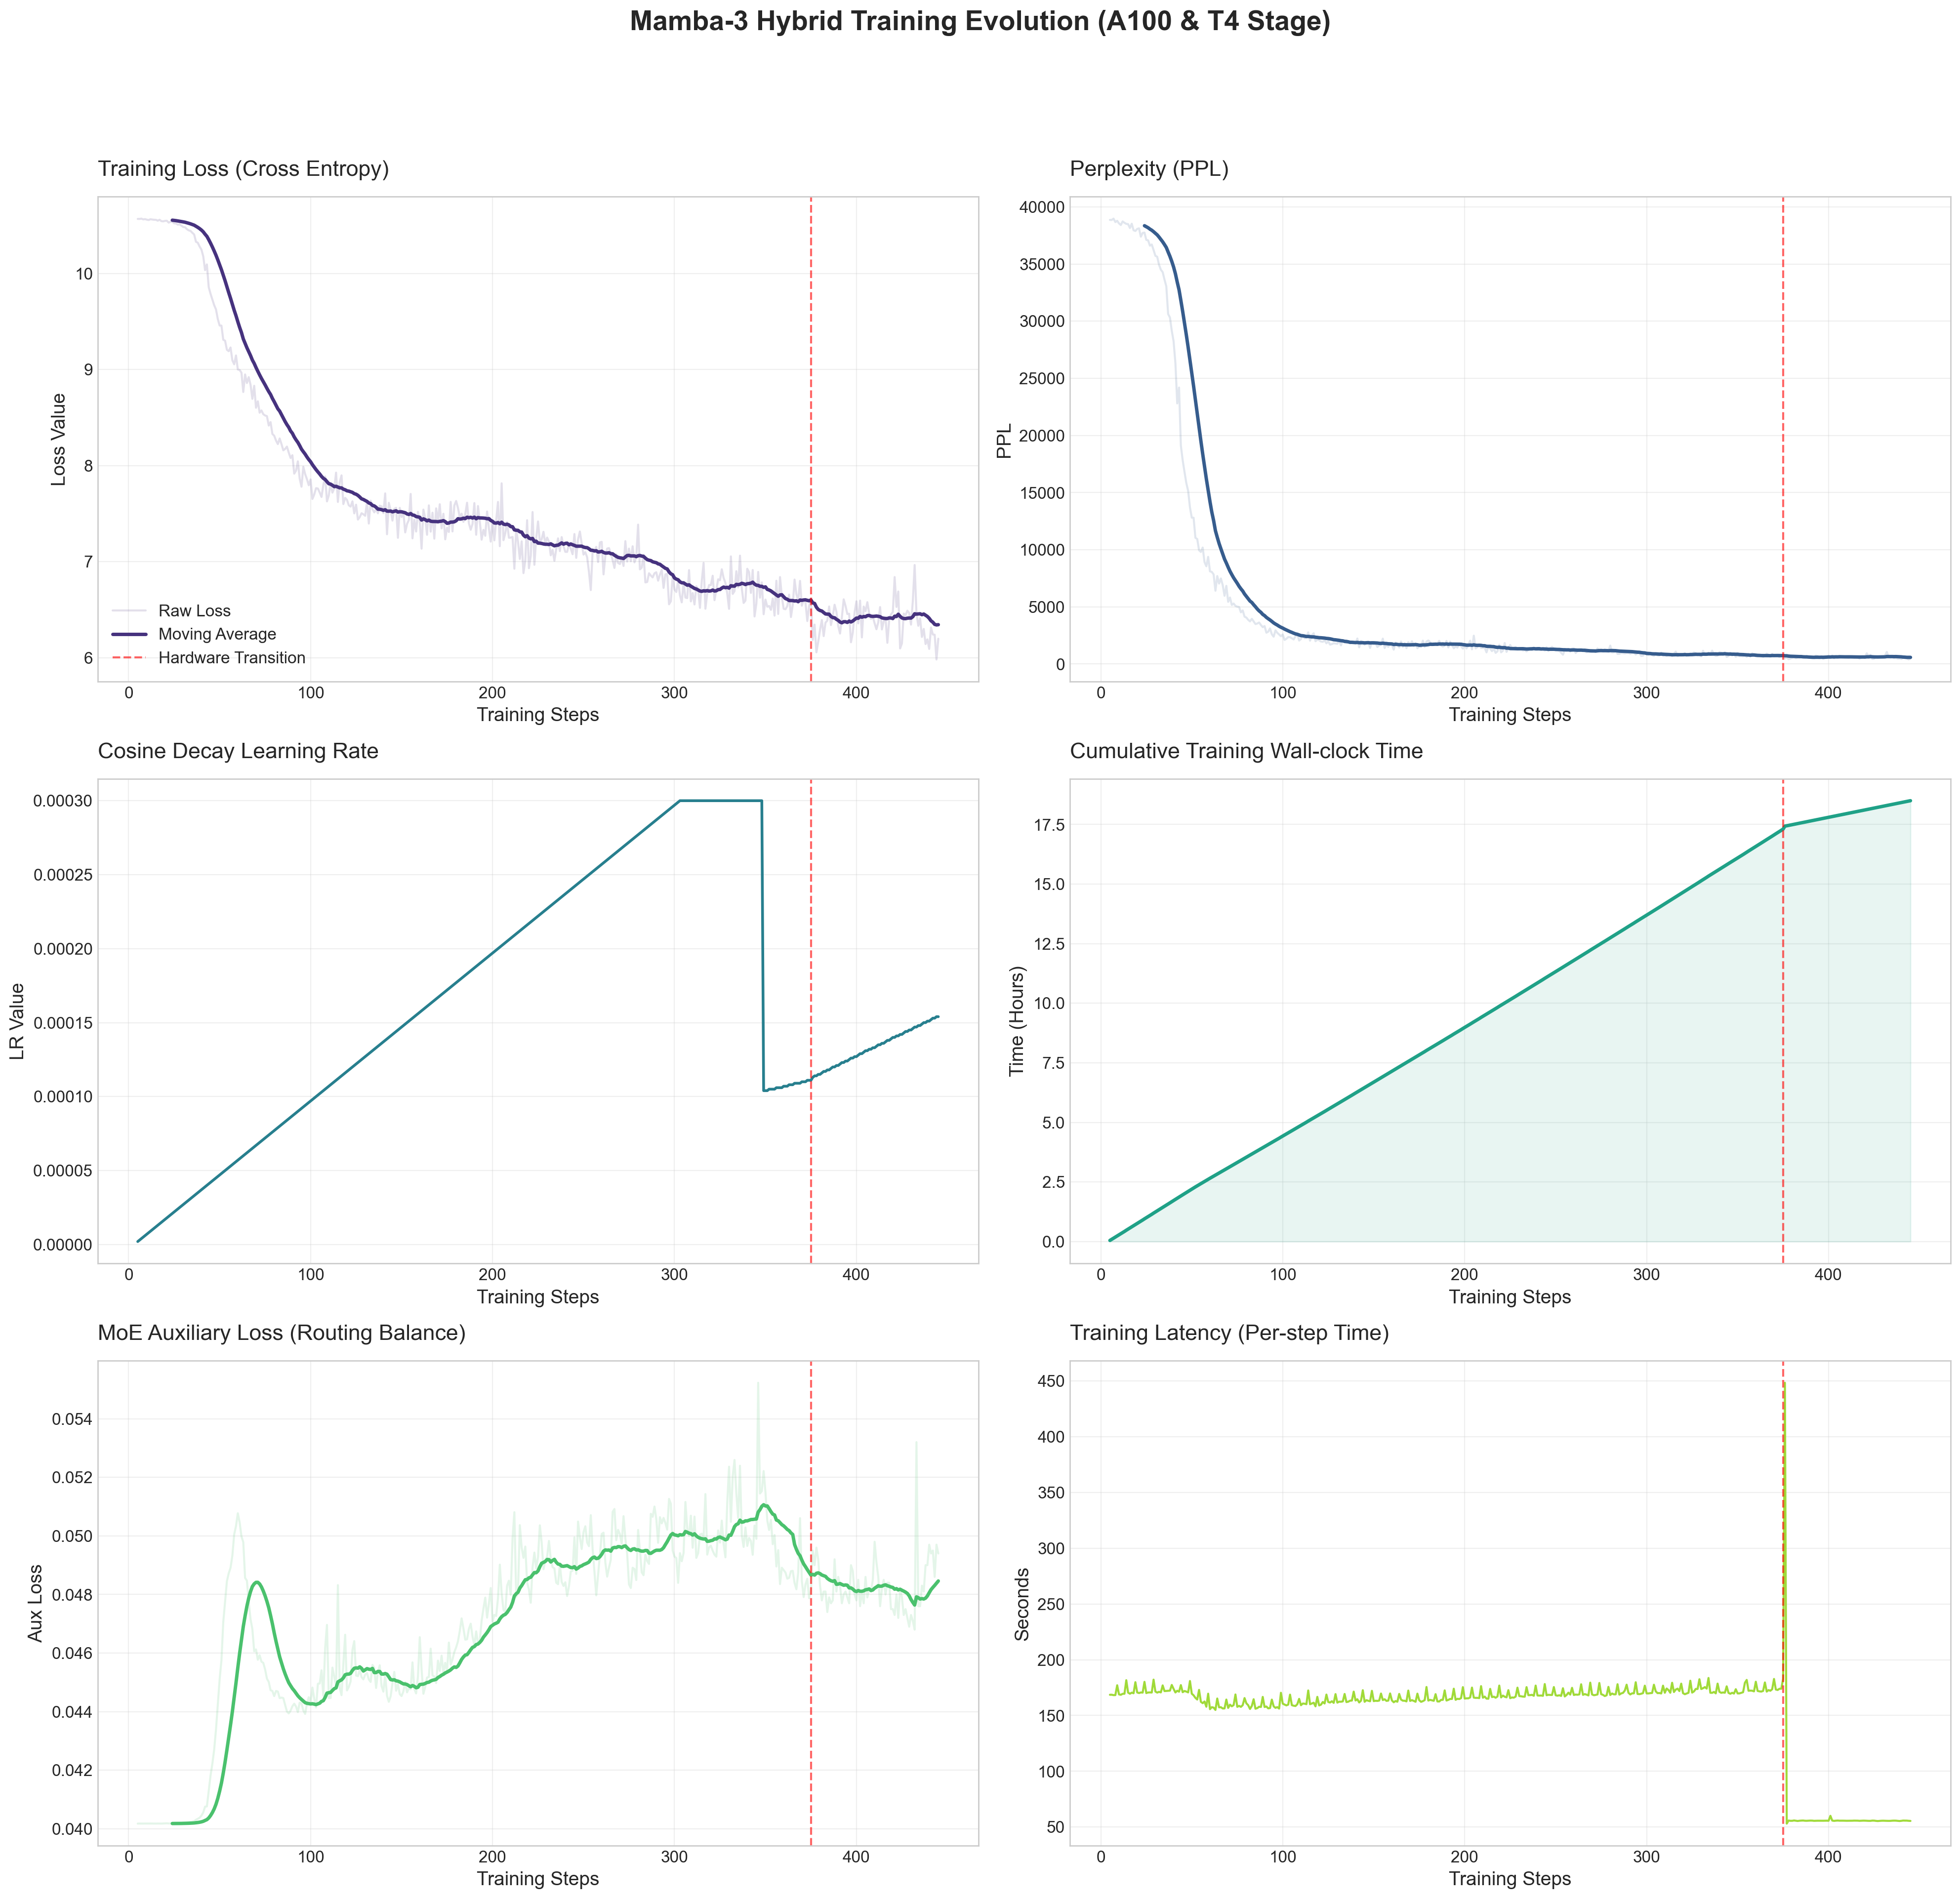


        MAMBA-3 HYBRID STAGE CONFIGURATION
Architecture       : Mamba-3-KMoE (186.14M Params)
Stage 1 Platform   : NVIDIA A100 (80GB)
Stage 2 Platform   : NVIDIA T4 x 2 (Distributed)
Transition Step    : 375
Total Duration     : 18.50 Hours

                       MAMBA-3 PRE-TRAINING SCIENTIFIC SUMMARY
[Platform Info]      : NVIDIA A100 (Stage 1) -> NVIDIA T4 x 2 (Stage 2)
[Total Steps]        : 441
[Total Time]         : 18.50 Hours
[Average Step Time]  : 151.01 Seconds
[Current Loss]       : 6.1973
[Current PPL]        : 491.4300
[Throughput]         : 135.62 Tokens/Sec


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'
import seaborn as sns
import math
import os

# ==========================================
# 論文等級分析配置 (Hybrid Stage Analysis)
# ==========================================

A100_CSV = "/Users/hungwei/Downloads/colab_training_log.csv"
T4_CSV = "/Users/hungwei/Desktop/Proj/Mamba3-XR/t4_training_log.csv"
PLATFORM_INFO = "NVIDIA A100 (Stage 1) -> NVIDIA T4 x 2 (Stage 2)"

WARMUP = 500
TOTAL_STEPS = 10000
GLOBAL_BATCH = 40
SEQ_LEN = 512

MOVING_WINDOW = 20

# 設定繪圖風格
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 20,
    'axes.grid': True,
    'grid.alpha': 0.3
})
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    sns.set_style("whitegrid")

palette = sns.color_palette("viridis", 6)

# ==============================
# 1. 數據讀取與合併
# ==============================

df_a100 = pd.read_csv(A100_CSV)
df_t4 = pd.read_csv(T4_CSV)

# 標記轉折點
transition_step = df_a100['step'].max()

# 合併數據
df = pd.concat([df_a100, df_t4], ignore_index=True)
df = df.sort_values("step").drop_duplicates(subset=['step'])

# 計算累積時間 (小時)
df["cum_time_hrs"] = df["step_time"].cumsum() / 3600
total_training_hrs = df["cum_time_hrs"].iloc[-1]

# 指標平滑
df["loss_ma"] = df["loss"].rolling(MOVING_WINDOW).mean()
df["ppl_ma"] = df["ppl"].rolling(MOVING_WINDOW).mean()
df["aux_ma"] = df["aux_loss"].rolling(MOVING_WINDOW).mean()

# ==============================
# 2. 視覺化分析 (3x2 佈局)
# ==============================

fig, axes = plt.subplots(3, 2, figsize=(20, 20))
fig.suptitle(f"Mamba-3 Hybrid Training Evolution (A100 & T4 Stage)\n", fontweight='bold')

def add_vlines(ax):
    ax.axvline(x=transition_step, color='red', linestyle='--', alpha=0.6, label='Hardware Transition')

# --- (A) Training Loss ---
ax = axes[0, 0]
ax.plot(df["step"], df["loss"], color=palette[0], alpha=0.15, label="Raw Loss")
ax.plot(df["step"], df["loss_ma"], color=palette[0], linewidth=2.5, label="Moving Average")
add_vlines(ax)
ax.set_title("Training Loss (Cross Entropy)", loc='left', pad=15)
ax.set_xlabel("Training Steps")
ax.set_ylabel("Loss Value")
ax.legend()

# --- (B) Perplexity (PPL) ---
ax = axes[0, 1]
ax.plot(df["step"], df["ppl"], color=palette[1], alpha=0.15)
ax.plot(df["step"], df["ppl_ma"], color=palette[1], linewidth=2.5)
add_vlines(ax)
ax.set_yscale("linear")
ax.set_title("Perplexity (PPL)", loc='left', pad=15)
ax.set_xlabel("Training Steps")
ax.set_ylabel("PPL")

# --- (C) Learning Rate Schedule ---
ax = axes[1, 0]
ax.plot(df["step"], df["lr"], color=palette[2], linewidth=2)
add_vlines(ax)
ax.set_title("Cosine Decay Learning Rate", loc='left', pad=15)
ax.set_xlabel("Training Steps")
ax.set_ylabel("LR Value")

# --- (D) Cumulative Time (Hours) ---
ax = axes[1, 1]
ax.plot(df["step"], df["cum_time_hrs"], color=palette[3], linewidth=2.5)
ax.fill_between(df["step"], df["cum_time_hrs"], color=palette[3], alpha=0.1)
add_vlines(ax)
ax.set_title("Cumulative Training Wall-clock Time", loc='left', pad=15)
ax.set_xlabel("Training Steps")
ax.set_ylabel("Time (Hours)")

# --- (E) MoE Auxiliary Loss ---
ax = axes[2, 0]
ax.plot(df["step"], df["aux_loss"], color=palette[4], alpha=0.15)
ax.plot(df["step"], df["aux_ma"], color=palette[4], linewidth=2.5)
add_vlines(ax)
ax.set_title("MoE Auxiliary Loss (Routing Balance)", loc='left', pad=15)
ax.set_xlabel("Training Steps")
ax.set_ylabel("Aux Loss")

# --- (F) Step Time (Seconds) ---
ax = axes[2, 1]
ax.plot(df["step"], df["step_time"], color=palette[5], linewidth=1.5)
add_vlines(ax)
ax.set_title("Training Latency (Per-step Time)", loc='left', pad=15)
ax.set_xlabel("Training Steps")
ax.set_ylabel("Seconds")

plt.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

# ==============================
# 3. 訓練配置與摘要
# ==============================

print("\n" + "="*60)
print("        MAMBA-3 HYBRID STAGE CONFIGURATION")
print("="*60)
print(f"Architecture       : Mamba-3-KMoE (186.14M Params)")
print(f"Stage 1 Platform   : NVIDIA A100 (80GB)")
print(f"Stage 2 Platform   : NVIDIA T4 x 2 (Distributed)")
print(f"Transition Step    : {transition_step}")
print(f"Total Duration     : {total_training_hrs:.2f} Hours")
print("="*60 + "\n")

print("="*80)
print("                       MAMBA-3 PRE-TRAINING SCIENTIFIC SUMMARY")
print("="*80)
print(f"[Platform Info]      : {PLATFORM_INFO}")
print(f"[Total Steps]        : {len(df)}")
print(f"[Total Time]         : {total_training_hrs:.2f} Hours")
print(f"[Average Step Time]  : {df['step_time'].mean():.2f} Seconds")
print(f"[Current Loss]       : {df['loss'].iloc[-1]:.4f}")
print(f"[Current PPL]        : {df['ppl'].iloc[-1]:.4f}")
print(f"[Throughput]         : {((len(df) * GLOBAL_BATCH * SEQ_LEN) / (total_training_hrs * 3600)):.2f} Tokens/Sec")
print("="*80)
